In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Part 1: Simulated annealing for the TSP
def tour_length(route, points):
    """Total Euclidean length of the closed tour visiting points in the given order."""
    pts = points[route]
    diffs = pts - np.roll(pts, -1, axis=0)
    return np.sqrt((diffs ** 2).sum(axis=1)).sum()

def tour_cost(route, cost_matrix):
    """Total cost of the closed tour visiting cities in the given order under a (possibly asymmetric) cost matrix."""
    return cost_matrix[route, np.roll(route, -1)].sum()

def propose_swap(route):
    """Propose a new route by swapping two randomly chosen positions on the route."""
    new_route = route.copy()
    i, j = np.random.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

def propose_reverse(route):
    """Propose a new route by reversing a randomly chosen segment of the route."""
    n = len(route)
    i, j = sorted(np.random.choice(n, size=2, replace=False))
    new_route = route.copy()
    new_route[i:j + 1] = new_route[i:j + 1][::-1]
    return new_route

def cooling_inv_sqrt(k):
    """Cooling schedule T_k = 1 / sqrt(1 + k)."""
    return 1.0 / np.sqrt(1 + k)

def cooling_inv_log(k):
    """Cooling schedule T_k = 1 / ln(2 + k)."""
    return 1.0 / np.log(2 + k)

def simulated_annealing_tsp(n_cities, cost_fn, n_iter, cooling, propose=propose_swap, seed=42):
    """Simulated annealing for the TSP with a general cost function.

    Starts from a random route and repeatedly proposes a new route using `propose`.
    A proposal that decreases the cost is always accepted; one that increases it is
    accepted with probability exp(-(new_cost - cost) / T_k), where T_k is given by
    `cooling(k)`. Returns the best route found, its cost, and the cost history.
    """
    np.random.seed(seed)
    route = np.random.permutation(n_cities)
    cost = cost_fn(route)

    best_route, best_cost = route.copy(), cost
    costs = np.empty(n_iter)

    for k in range(n_iter):
        T = cooling(k)
        new_route = propose(route)
        new_cost = cost_fn(new_route)

        if new_cost < cost or np.random.uniform() < np.exp(-(new_cost - cost) / T):
            route, cost = new_route, new_cost
            if cost < best_cost:
                best_route, best_cost = route.copy(), cost

        costs[k] = cost

    return best_route, best_cost, costs

def plot_route(points, route, ax=None, title=None):
    """Plot the points and the closed tour connecting them in the given order."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    tour = points[np.append(route, route[0])]
    ax.plot(tour[:, 0], tour[:, 1], 'o-')
    ax.set_aspect('equal')
    if title:
        ax.set_title(title)
    return fig, ax

n = 20, n_iter = 5000
Best tour length: 6.2574


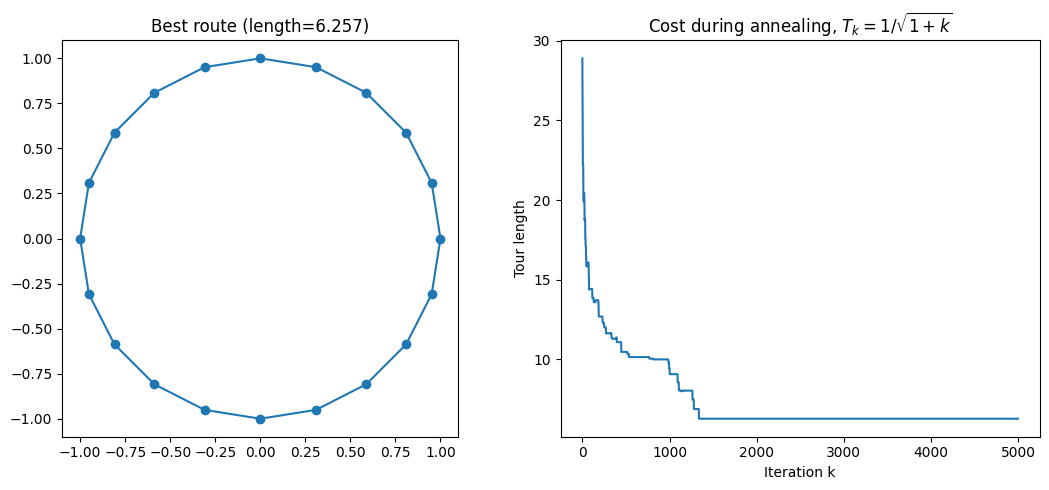

In [22]:
# Random points on a circle
n = 20
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
points = np.column_stack((np.cos(theta), np.sin(theta)))

n_iter = 5000
best_route, best_cost, costs = simulated_annealing_tsp(n, lambda r: tour_length(r, points), n_iter, cooling_inv_sqrt)

print(f"n = {n}, n_iter = {n_iter}")
print(f"Best tour length: {best_cost:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_route(points, best_route, ax=axes[0], title=f"Best route (length={best_cost:.3f})")
axes[1].plot(costs)
axes[1].set_xlabel("Iteration k")
axes[1].set_ylabel("Tour length")
axes[1].set_title(r"Cost during annealing, $T_k = 1/\sqrt{1+k}$")
fig.tight_layout()
plt.show()

SA best tour length:      8.8677
Optimal (ordered) length: 6.2574


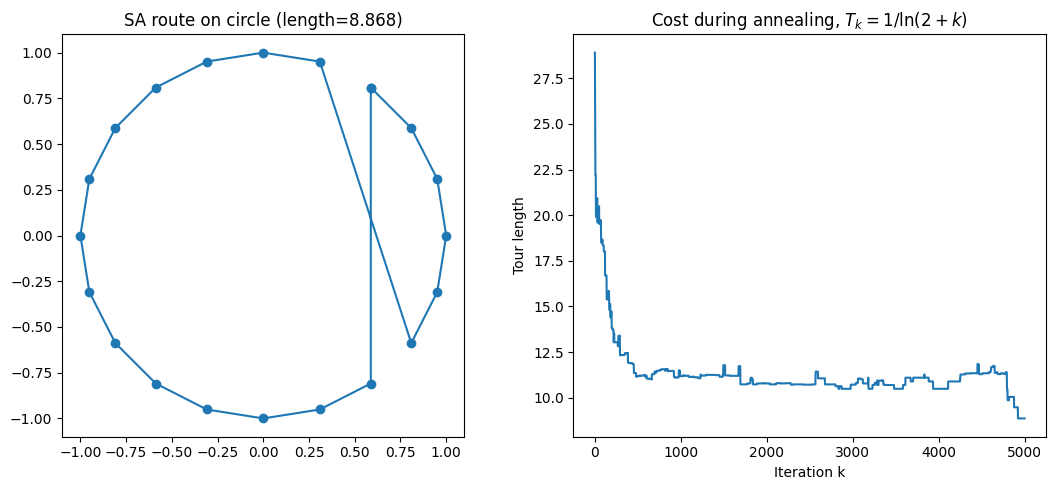

In [23]:
# Sanity check: points on a circle, where the optimal route is known to be the
# one that visits the points in angular order (going around the circle once).
n_circle = 20
theta = np.linspace(0, 2 * np.pi, n_circle, endpoint=False)
circle_points = np.column_stack((np.cos(theta), np.sin(theta)))

best_route_c, best_cost_c, costs_c = simulated_annealing_tsp(n_circle, lambda r: tour_length(r, circle_points), n_iter, cooling_inv_log)

optimal_cost = tour_length(np.arange(n_circle), circle_points)
print(f"SA best tour length:      {best_cost_c:.4f}")
print(f"Optimal (ordered) length: {optimal_cost:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_route(circle_points, best_route_c, ax=axes[0], title=f"SA route on circle (length={best_cost_c:.3f})")
axes[1].plot(costs_c)
axes[1].set_xlabel("Iteration k")
axes[1].set_ylabel("Tour length")
axes[1].set_title(r"Cost during annealing, $T_k = 1/\ln(2+k)$")
fig.tight_layout()
plt.show()

Cost matrix: 20 x 20, symmetric: False
Best route: [15 13  1  8 18 14 11  5 16  6 17  2 10 19 12  3  0  7  4  9]
Best cost:  878.00


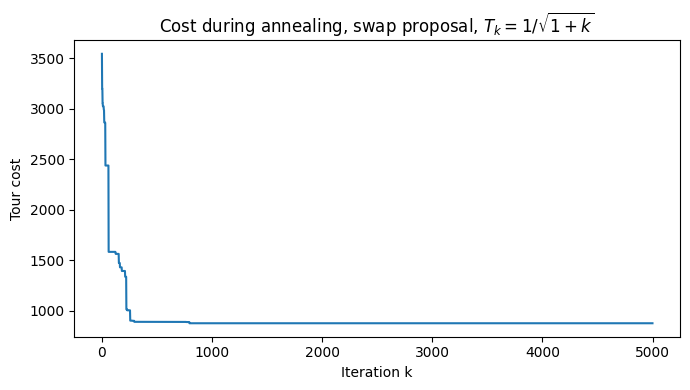

In [27]:
# Part 2: General travel costs -- apply SA to the cost matrix from cost.csv
cost_matrix = np.loadtxt("cost.csv", delimiter=",")
n_cities = cost_matrix.shape[0]

print(f"Cost matrix: {n_cities} x {n_cities}, symmetric: {np.allclose(cost_matrix, cost_matrix.T)}")

n_iter = 5000
best_route, best_cost, costs = simulated_annealing_tsp(n_cities, lambda r: tour_cost(r, cost_matrix), n_iter, cooling_inv_sqrt, propose=propose_swap)

print(f"Best route: {best_route}")
print(f"Best cost:  {best_cost:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(costs)
plt.xlabel("Iteration k")
plt.ylabel("Tour cost")
plt.title(r"Cost during annealing, swap proposal, $T_k = 1/\sqrt{1+k}$")
plt.tight_layout()
plt.show()

swap, T=1/sqrt(1+k)                 best cost = 878.00
swap, T=1/ln(2+k)                   best cost = 878.00
reverse, T=1/sqrt(1+k)              best cost = 795.00
reverse, T=1/ln(2+k)                best cost = 795.00


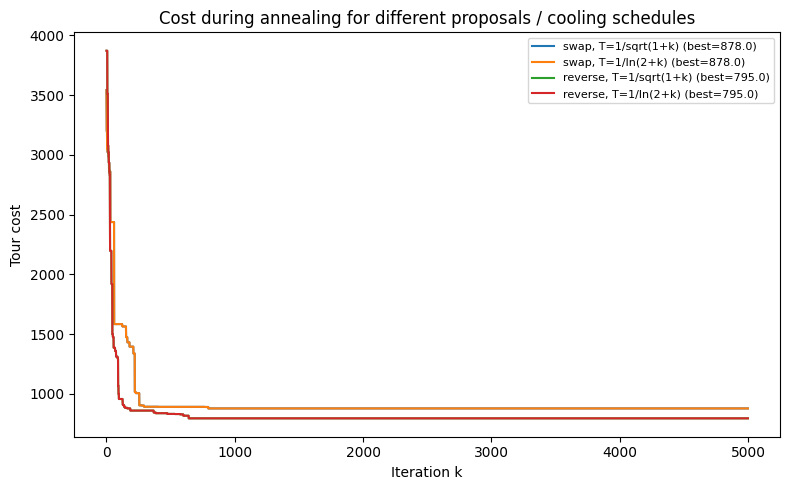

In [30]:
# Experiment: compare proposal mechanisms and cooling schedules on the cost matrix
configs = [
    ("swap, T=1/sqrt(1+k)", propose_swap, cooling_inv_sqrt),
    ("swap, T=1/ln(2+k)", propose_swap, cooling_inv_log),
    ("reverse, T=1/sqrt(1+k)", propose_reverse, cooling_inv_sqrt),
    ("reverse, T=1/ln(2+k)", propose_reverse, cooling_inv_log),
]

n_iter = 5000
results = {}
for name, propose, cooling in configs:
    _, best_cost_cfg, costs_cfg = simulated_annealing_tsp(
        n_cities, lambda r: tour_cost(r, cost_matrix), n_iter, cooling, propose=propose
    )
    results[name] = (best_cost_cfg, costs_cfg)
    print(f"{name:35s} best cost = {best_cost_cfg:.2f}")

plt.figure(figsize=(8, 5))
for name, (best_cost_cfg, costs_cfg) in results.items():
    plt.plot(costs_cfg, label=f"{name} (best={best_cost_cfg:.1f})")
plt.xlabel("Iteration k")
plt.ylabel("Tour cost")
plt.title("Cost during annealing for different proposals / cooling schedules")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()